In [12]:
import matplotlib.pyplot as plt
import japanize_matplotlib
import numpy as np
import json
import os
import pandas as pd

正解のjsonファイル(dev.jsonなど)と正解率のファイル(math-evalを実行することにより得られた結果のjsonファイル)を読み込む

In [2]:
target_json = "../math-eval/examples/dev.jsonl"
with open(target_json, "r") as f:
    target_data = [json.loads(line) for line in f]
accuracy_json = "../math-eval/accuracy/acc_4_1_inst_1024.json"
with open(accuracy_json, "r") as f:
    accuracy_data = json.load(f)["detailed_results"]
target_data, accuracy_data

([{'id': 1,
   'category': '中1',
   'unit': '一次方程式',
   'problem': '1個50円のみかんと1個120円のりんごを合わせて10個買ったら、代金の合計が920円となった。この時買ったみかんの個数を求めなさい。',
   'solution': '4'},
  {'id': 2,
   'category': '中1',
   'unit': '一次方程式',
   'problem': '次の方程式を解きなさい。\n\n$$\\frac{2}{5}x - 4 = \\frac{x}{3}$$',
   'solution': '$$60$$'},
  {'id': 3,
   'category': '中1',
   'unit': '一次方程式',
   'problem': '次の方程式を解きなさい。\n\n$$x - 3 = - 2$$',
   'solution': '$$1$$'},
  {'id': 4,
   'category': '中1',
   'unit': '文字式',
   'problem': '$x = - \\frac{1}{4}$ののとき、$- x^{3}$の値を求めなさい。',
   'solution': '$$\\frac{1}{64}$$'},
  {'id': 5,
   'category': '中1',
   'unit': '文字式',
   'problem': '次の式を計算しなさい\n\n$$- 6(3x - 7) + 3(3x - 8)$$',
   'solution': '$$- 9x + 18$$'},
  {'id': 6,
   'category': '中1',
   'unit': '文字式',
   'problem': '次の計算をしなさい。\n\n$$5a - 8a$$',
   'solution': '$$- 3a$$'},
  {'id': 7,
   'category': '中1',
   'unit': '文字式',
   'problem': '次の計算をしなさい。\n\n$$\\frac{3}{4}b \\times 24$$',
   'solution': '$$18b$$'},
  {'id': 8,
 

pandasのDataFrame形式に変換

In [7]:
df = pd.DataFrame(target_data)
columns = ["id", "category", "unit"]
df = df[columns]
df["T_or_F"] = [accuracy_data[str(idx)] for idx in df["id"]]
df

,id,category,unit,T_or_F
0,1,中1,一次方程式,True
1,2,中1,一次方程式,True
2,3,中1,一次方程式,True
3,4,中1,文字式,True
4,5,中1,文字式,True
...,...,...,...,...
95,96,IIIC,積分,False
96,97,IIIC,ベクトル,False
97,98,IIIC,ベクトル,True
98,99,IIIC,平面上の曲線と複素数平面,False


<Axes: xlabel='unit'>

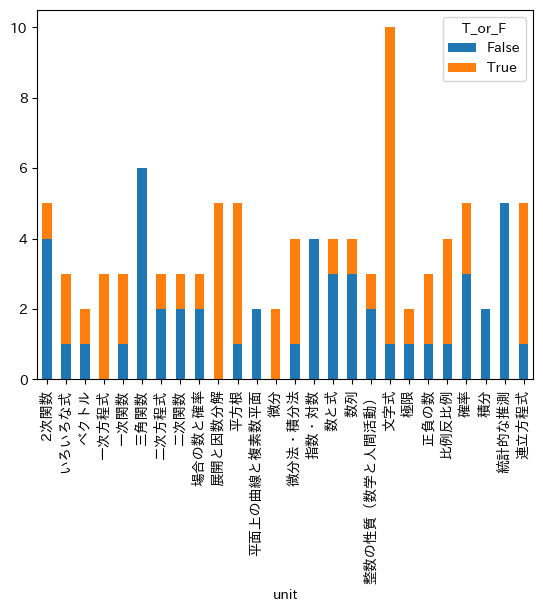

In [13]:
counts = df.groupby(['unit', 'T_or_F']).size().unstack(fill_value=0)
counts.plot(kind='bar', stacked=True)

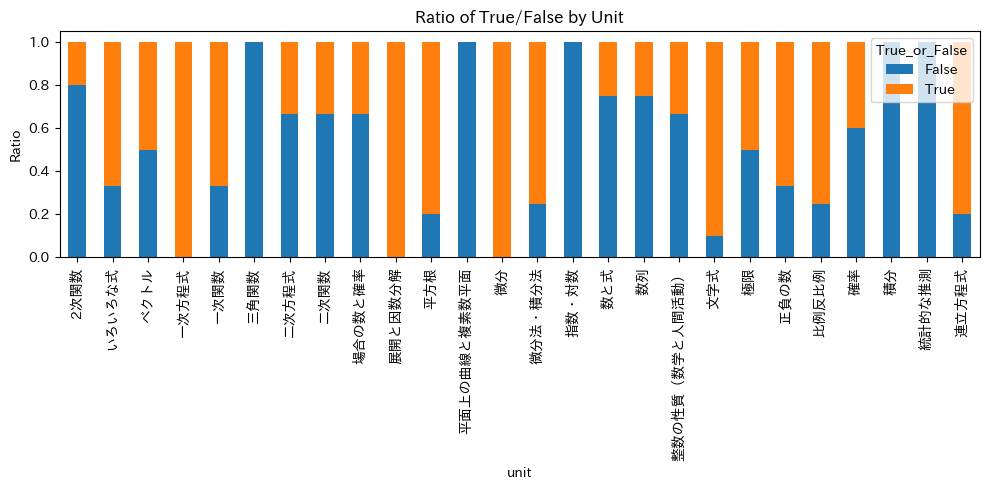

In [14]:
ratio = counts.div(counts.sum(axis=1), axis=0)
ratio.plot(kind='bar', stacked=True, figsize=(10, 5))
plt.ylabel("Ratio")
plt.title("Ratio of True/False by Unit")
plt.legend(title="True_or_False")

plt.tight_layout()
plt.show()